# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

I (jimmy :]) use MCMC to compute the effects of suppressing tail terms (1.5-3.5PN order, encompassing first-order tails to 2nd-order nonlinear Christodoulou memory) in the waveform. Of interest are the Bayes factor between the untouched waveform and variously suppressed waveforms as a multivariate function of the toggling parameters (lambda15 thru lambda35).

## PN Terms by Order
- 1.5PN: first-order tail term; 
- 2.5PN: Christodoulou memory term and corrections to the 1.5PN tail term; 
- 3PN: second-order tail/tail-of-tail term; 
- 3.5PN: Christodoulou memory correction

In [1]:
%load_ext autoreload
%autoreload 2

import lambdasMCMC as lmcmc
import matplotlib.pyplot as plt
import numpy as np
import thermo_error as te

In [ ]:
## Only NEED the <lnL> vs beta plot, but DO write functionality to make diagnostic plots like: 
# time/freq-series strain,
# \Delta\Psi vs f, **STARTED
# lnL vs iteration, **STARTED
# \vec{\theta} vs iteration, **STARTED
# MAYBE posterior corner plots (for 1-2 arbitrary sets of toggle params) and bayesograms
## lnZs are calculated with thermo_error.py

# default geometric temperature ladder (to be deprecated by adaptive ladder generation below)
#num_samples=10000
#num_chains=15
#temp0=3.4
#temp_ladder=temp0**(np.arange(num_chains))

In [2]:
### Adaptive ladder spacing
# Save <lnL> and \sigma_{lnL} estimates globally
tl_akima, avg_lnlikes_akima, lnlikes_stdevs_akima = lmcmc.construct_roughTIdata(2, 40)

Running PTMCMC to obtain mock <lnL>(beta) and \sigma_{lnL}(beta) curves...


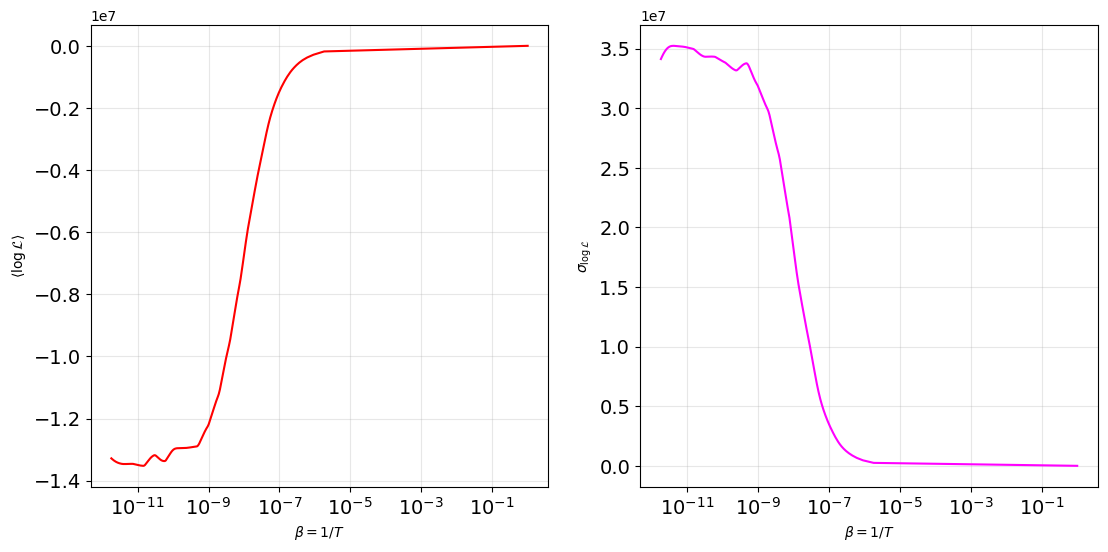

********************* CONSTRUCTING TEMP LADDER *********************
Ansatz: [1.  3.5]

*** Iteration #1 ***
First R: 0.9642023623400497
Next temperature after 3.5: 12.144521230145315.
Next R: 0.9722526497317852

*** Iteration #2 ***
Next temperature after 12.144521230145315: 43.1531976154939.
Next R: 1.0113924099307403

*** Iteration #3 ***
Next temperature after 43.1531976154939: 166.90730275486544.
Next R: 0.9858203544689982

*** Iteration #4 ***
Next temperature after 166.90730275486544: 646.9222565438147.
Next R: 0.9854170171115851

*** Iteration #5 ***
Next temperature after 646.9222565438147: 2153.6964888412.
Next R: 1.0297477627021154

*** Iteration #6 ***
Next temperature after 2153.6964888412: 4548.244397826471.
Next R: 0.9608365353630823

*** Iteration #7 ***
Next temperature after 4548.244397826471: 15962.06562287977.
Next R: 0.9289286957609486

*** Iteration #8 ***
Next temperature after 15962.06562287977: 593734340141.1364.
Next R: nan

****************##### Temperature l

In [26]:
# sanity check: plot Akima-splined <lnL> and \sigma vs \beta
akimafig,(axmu,axsig)=plt.subplots(1,2,figsize=(13,6))
axmu.plot(1./tl_akima, avg_lnlikes_akima(tl_akima), marker=None, color='red', label='<lnL>s')
axsig.plot(1./tl_akima, lnlikes_stdevs_akima(tl_akima), marker=None, color='magenta', label='sigmas')
axmu.set_ylabel(r'$\langle\log\mathcal{L}\rangle$')
axsig.set_ylabel(r'$\sigma_{\log\mathcal{L}}$')

for ax in (axmu,axsig):
    ax.set_xlabel(r'$\beta = 1/T$')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xscale('log')
plt.show()
adaptive_temp_ladder=lmcmc.construct_temp_ladder((tl_akima, avg_lnlikes_akima, lnlikes_stdevs_akima))

temp_ladder=adaptive_temp_ladder[:-1] # last chain is extremely extremely hot... is \sigma_lnL too large at high temps? how fix?
num_samples=10000
num_chains=len(temp_ladder)
temp0=temp_ladder[1]

######### Running PTMCMC #1/2 for lambdavec=$\lambda15$=0.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########
Average PT swap acceptance rate: 0.17901813633520952
~~~(temp_ladder, Rbars)~~~
1.0 0.862
3.5 1.075
12.14 0.959
43.15 0.922
166.91 1.046
646.92 0.966
2153.7 0.758
4548.24 1.033
15962.07 0.0
~~~(temp_ladder, Pacc)~~~
1.0 0.17479674796747968
3.5 0.13696060037523453
12.14 0.1610381488430269
43.15 0.17698561601000626
166.91 0.1357098186366479
646.92 0.16604127579737335
2153.7 0.3320825515947467
4548.24 0.1485303314571607
15962.07 0.0
######### Running PTMCMC #2/2 for lambdavec=$\lambda15$=1.0, $\lambda25$=0.0, $\lambda3$=0.0, $\lambda35$=0.0 #########
Average PT swap acceptance rate: 0.20228168587022438
~~~(temp_ladder, Rbars)~~~
1.0 0.914
3.5 0.749
12.14 0.889
43.15 0.861
166.91 0.893
646.92 0.844
2153.7 0.986
4548.24 0.979
15962.07 0.0
~~~(temp_ladder, Pacc)~~~
1.0 0.19132807762280168
3.5 0.266525166767738
12.14 0.18496058217101274
43.15 0.20861127956337175
166.91 0.157

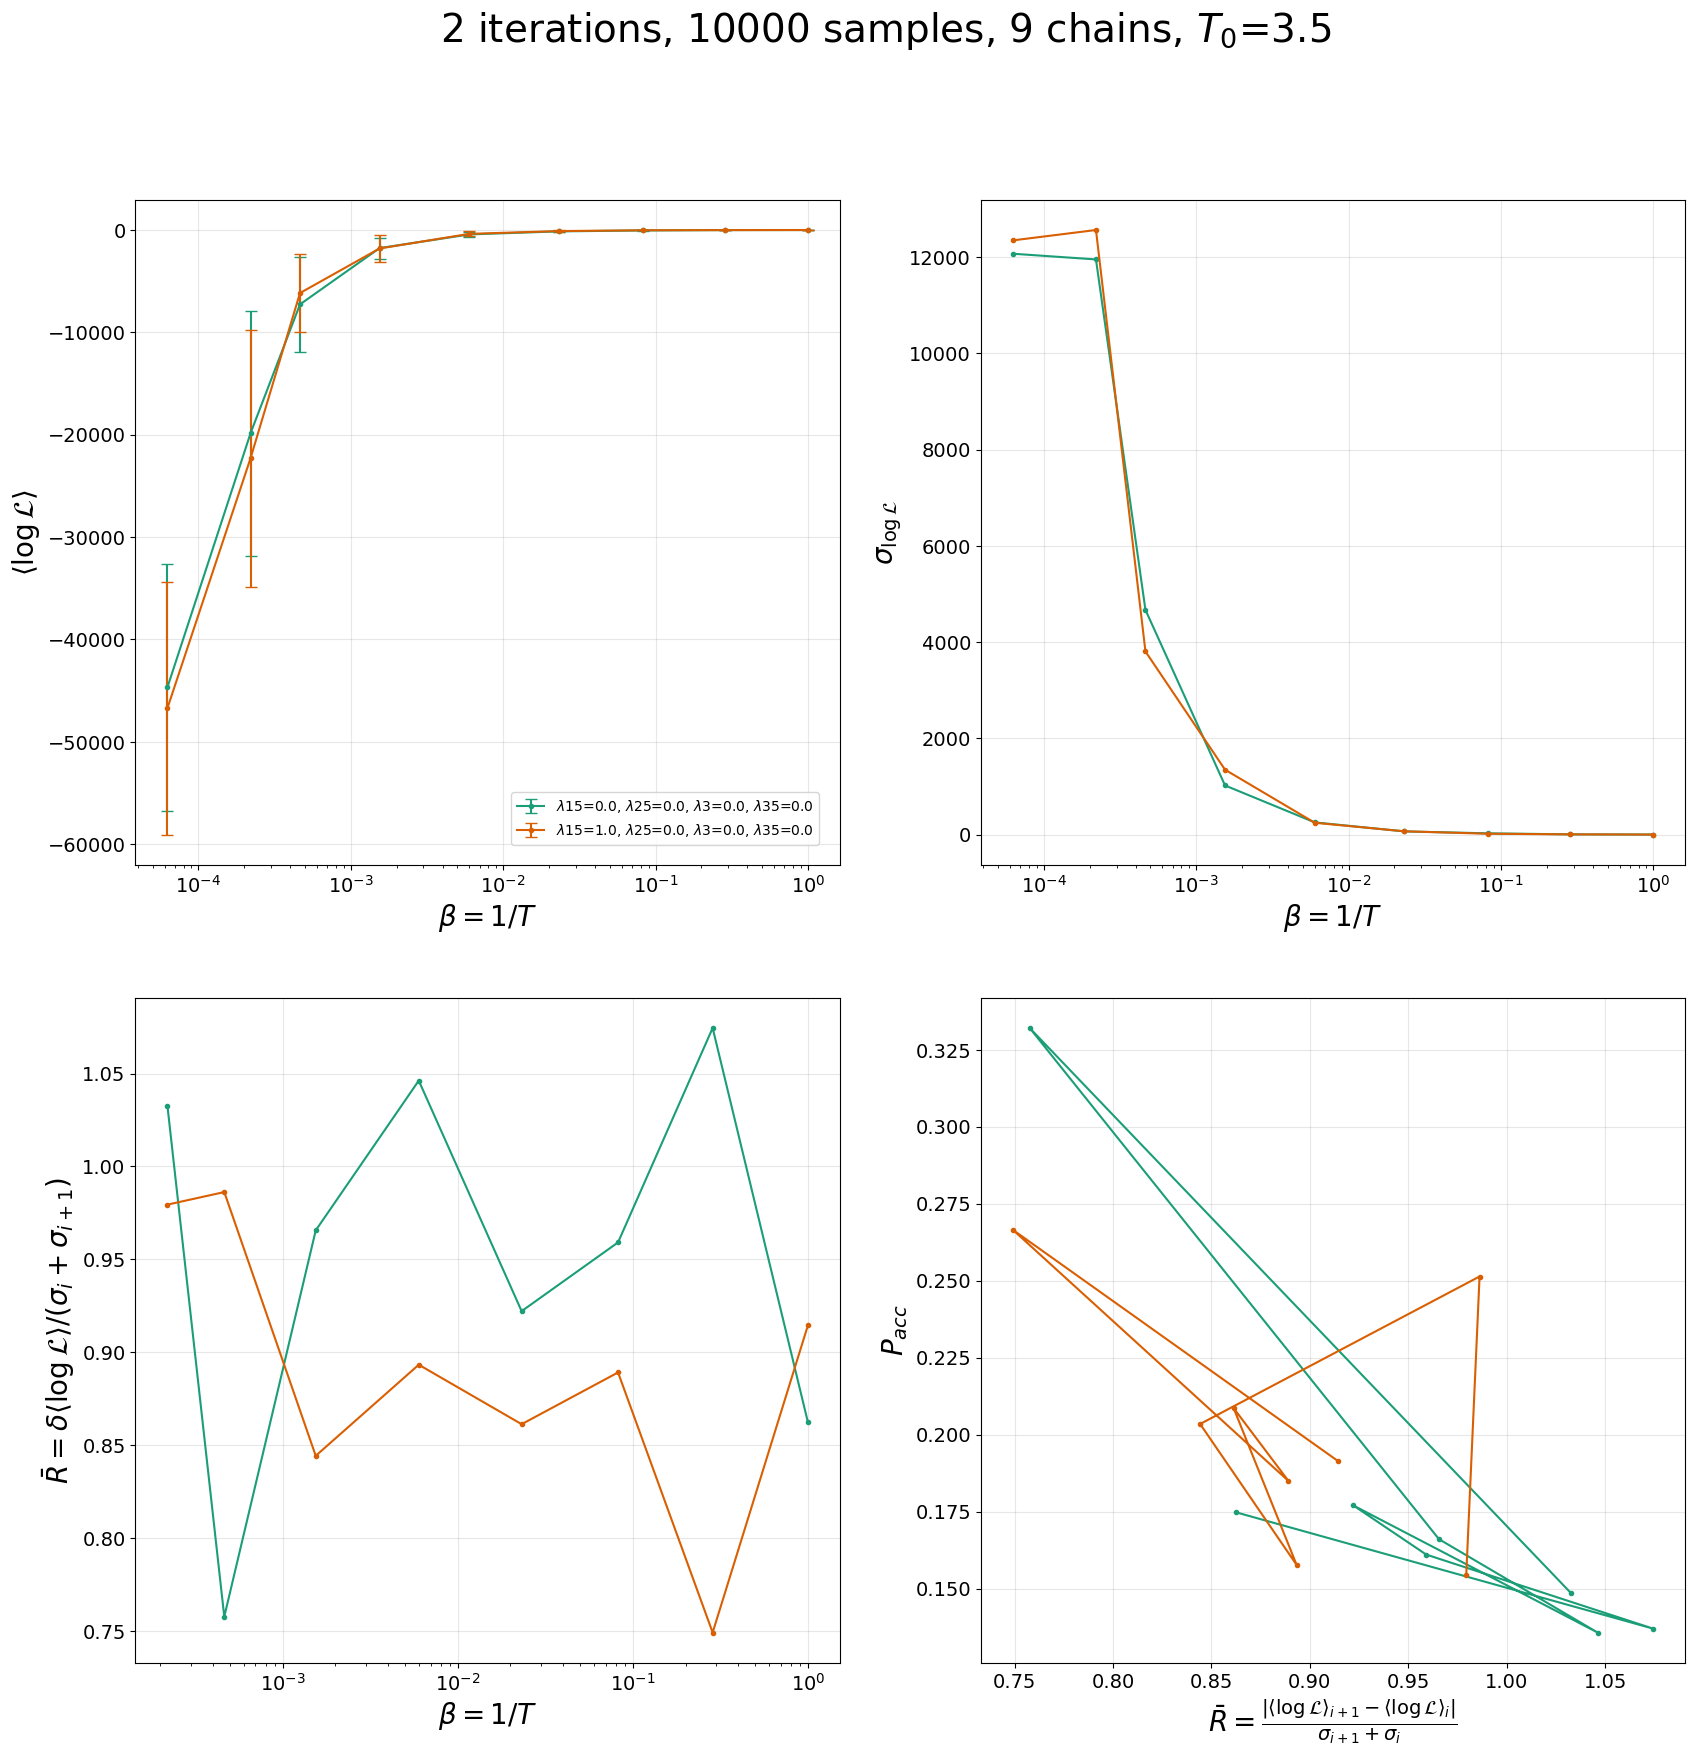

In [27]:
### Plot <lnL> vs. \beta for each chosen vector of lambda values
lambdas=list(zip(lmcmc.lambda15s, lmcmc.lambda25s, lmcmc.lambda3s, lmcmc.lambda35s))
num_lmcmciters=len(lambdas)

fig,((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,19))

colors=lmcmc.itercolors

__TIData__ = np.zeros(num_lmcmciters, dtype=lmcmc.TIData)


i=1
for lambda15, lambda25, lambda3, lambda35 in lambdas:
    lambdavec=rf'$\lambda15$={round(lambda15,2)}, $\lambda25$={round(lambda25,2)}, $\lambda3$={round(lambda3,2)}, $\lambda35$={round(lambda35,2)}'
    print(f'######### Running PTMCMC #{i}/{num_lmcmciters} for lambdavec={lambdavec} #########')

    ## Do PTMCMC for this set of lambda values
    samples, lnposts, acc_rates = lmcmc.PTMCMC_i(lambdas=[lambda15, lambda25, lambda3, lambda35], 
                                                   temp_ladder=temp_ladder,
                                                   num_samples=num_samples,
                                                   num_chains=num_chains)

    # obtain lnlikes for each beta
    lnlikes = lmcmc.lnlikes(temp_ladder, lnposts, num_samples)

    # Plot avg lnlikes against betas
    betas, avg_lnlikes, lnlikes_stdevs = lmcmc.avglnlikes_vs_betas(temp_ladder, lnposts, num_samples)
    ax1.errorbar(betas, avg_lnlikes, yerr=lnlikes_stdevs, capsize=4, marker='.', color=colors[i-1], label=lambdavec)
    ax2.plot(betas, lnlikes_stdevs, marker='.', color=colors[i-1], label=lambdavec)

    ## save data (to be splined and then integrated) ##
    __TIData__[i-1]=lmcmc.TIData(betas, lnlikes, avg_lnlikes, lnlikes_stdevs, lambdavec, colors[i-1], i) # thermo_error.py strictly takes hottest chains first




    ## Examine ladder spacing
    # Calculate overlap factors (alphas)
    alphas=np.zeros(len(betas)-1)
    for j in range(len(betas)-1):
        avg_lnlike_1, avg_lnlike_2 = avg_lnlikes[j], avg_lnlikes[j+1]
        lnlikes_stdev_1, lnlikes_stdev_2 = lnlikes_stdevs[j], lnlikes_stdevs[j+1]
        alphas[j]=lmcmc.alpha_overlap(avg_lnlike_1, lnlikes_stdev_1, avg_lnlike_2, lnlikes_stdev_2)

    # Calculate R-statistic as a fxn of temperature
    B,Rs=lmcmc.ladder_spacing_ratio(temp_ladder, avg_lnlikes, lnlikes_stdevs, alphas, print_chains=False, haxis='B')
    B,Rbars=lmcmc.ladder_spacing_ratio(temp_ladder, avg_lnlikes, lnlikes_stdevs, alphas=np.full(len(alphas),1.), print_chains=False, haxis='B') # normalized R-statistic
    ax3.plot(B[:-1],Rbars[:-1], marker='.', color=colors[i-1], label=lambdavec) # don't care about the hottest chain, it compares w/ nothing

    # Examine PT swap acceptance rates as a fxn of Rbar=R[alpha=1]
    Pacc=acc_rates['PT_swap']
    avgPTswapaccrate=np.mean(Pacc[:-1]) # do NOT include acceptance rate of swaps for the hottest chain, because that doesn't get swapped with anything hotter (duh!)
    ax4.plot(Rbars[:-1],Pacc[:-1], marker='.', color=colors[i-1], label=lambdavec)

    print(f'Average PT swap acceptance rate: {avgPTswapaccrate}')
    print(f'~~~(temp_ladder, Rbars)~~~')
    for T, Rbar in list(zip(temp_ladder,Rbars)):
        print(round(T,2), round(Rbar,3))
    print(f'~~~(temp_ladder, Pacc)~~~')
    for T, P in list(zip(temp_ladder,Pacc)):
        print(round(T,2), P)

    i+=1 # finish iteration


# Decorate the plots :)
fig.suptitle(rf'{num_lmcmciters} iterations, {num_samples} samples, {num_chains} chains, $T_0$={temp0}', fontsize=28)
ax1.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02))
ax1.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax1.set_ylabel(r'$\langle\log\mathcal{L}\rangle$', fontsize=20)
ax2.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax2.set_ylabel(r'$\sigma_{\log\mathcal{L}}$', fontsize=20)
ax3.set_xlabel(r'$\beta = 1 / T$', fontsize=20)
ax3.set_ylabel(r'$\bar{R} = \delta\langle\log\mathcal{L}\rangle / (\sigma_{i}+\sigma_{i+1})$', fontsize=20)

#*********** see what this looks like for regular R, not Rbar, and ask Neil if the alpha factor is even relevant here ***********
ax4.set_xlabel(r'$\bar{R} = \frac{|\langle\log\mathcal{L}\rangle_{i+1}-\langle\log\mathcal{L}\rangle_{i}|}{\sigma_{i+1}+\sigma_{i}}$', fontsize=20)
ax4.set_ylabel(r'$P_{acc}$', fontsize=20)


for ax in (ax1, ax2, ax3, ax4):
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)

ax1.set_xscale('log')
ax2.set_xscale('log')
ax3.set_xscale('log')


plt.show()

In [ ]:
### Evidence calculations (with Neil splining)

# load TIData.lnlikes, TIData.betas into a .dat file to run through thermo_error.py
for TIData in __TIData__:
    dat=lmcmc.construct_te_dattab(TIData.betas, TIData.lnlikes)
    path=f'lnlikechain_{TIData.filenum}.dat'
    np.savetxt(path, dat, fmt='%.12g')

Inferred 9 temperatures and 8000 samples from lnlikechain_1.dat

 Hottest chain beta = 6.264853e-05  log(beta) = -9.677970

Starting bootstrap estimate of correlation matrix
average number of chunks = 73  spread = 15.861281
least chunks = 500 for chain 1
most  chunks = 90 for chain 5
chunks = 41  samples per chunk = 195.121951
shrink = 0.999009

Average correlation of neighboring chains = 0.001039

Trapezoid integrand in beta -38.360725
Trapezoid integrand in ln(beta) -26.580482, statistical error 0.892285,  discretization error 2.641929
Initial Spline Evidence Estimate = -33.333216

 Average Evidence using ln(beta) -30.011748
 Sigma 0.596240


 Average Evidence using beta -30.012208
 Sigma 0.596249


 Average (Base 2) KL post-prior 38.808911
 Sigma 0.881212


 Average (Base 2) KL prior-post 63980.798708
 Sigma 1669.905865


 Average (Base 2) J metric 64019.607619
 Sigma 1670.227539



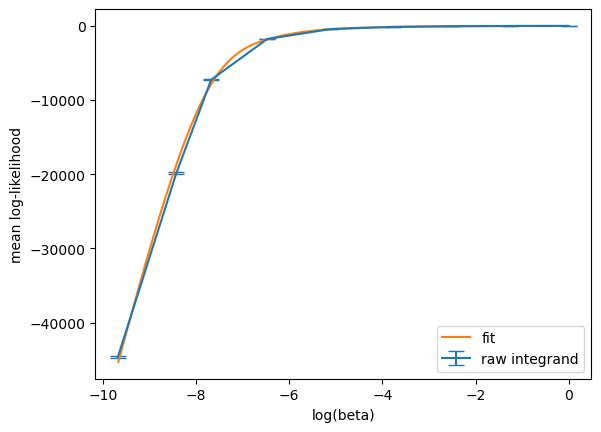

In [52]:
# Run .dat file of lnL chains through thermo_error.py
# Need support for customly-named outputs so that Neil's script doesn't simply rewrite all the output files for each iteration 
!python thermo_error.py lnlikechain_1.dat --steps 100000 --bootstrap-steps 10000

# Display some results
raw = np.loadtxt("rawintegrand.dat")
fit = np.loadtxt("fit.dat")

x = raw[:, 0]
y = raw[:, 1]
err = raw[:, 2]

plt.errorbar(x, y, yerr=err, capsize=6, label="raw integrand")
plt.plot(fit[:, 0], fit[:, 1], "-", label="fit")
plt.xlabel("log(beta)")
plt.ylabel("mean log-likelihood")
plt.legend()
plt.show()

In [ ]:
#### funny: the logLchain.dat file has a gross mismatch btwn raw integrand and fit, but my lnlikechain_i.dat files don't? !!